# SPC Neural Optimization: Image-to-3D with Octrees

This tutorial demonstrates **neural rendering with Kaolin's Structured Point Cloud (SPC)** data structure.

## What You'll Learn

- **SPC Octree Representation**: Hierarchical sparse voxel representation
- **Differentiable Rendering**: Using `kaolin.render.spc.unbatched_raytrace`
- **Volume Rendering**: Using `kaolin.render.spc.exponential_integration`
- **Neural Optimization**: Learning 3D structure from 2D images


## Setup and Imports


In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import kaolin as kal

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

print(f"\nKaolin version: {kal.__version__}")


Using device: cuda
GPU: NVIDIA GeForce RTX 4090
CUDA Version: 12.9

Kaolin version: 0.18.0


## Configuration

Adjust these parameters to control quality vs. speed:


In [61]:
# Image settings
IMAGE_SIZE = 128  # Resolution for target image (128x128)                  

# SPC settings
SPHERE_RADIUS = 1.0  # Extent of the initial point cloud, in [-1, 1] space
SPC_LEVEL = 5  # Octree depth: resolution = 2^level = 32 voxels per axis
               # Level 4 = 16^3 (~4K voxels) - Very fast, lower quality
               # Level 5 = 32^3 (~32K voxels) - Balanced (RECOMMENDED)
               # Level 6 = 64^3 (~130K voxels) - High quality, slower
               # Level 7 = 128^3 (~2M voxels) - Very slow, may need more batching

# Optimization settings
NUM_ITERATIONS = 300  # Training iterations (200-500 recommended)
LEARNING_RATE = 0.01  # Learning rate for optimization

# Visualization
PLOT_EVERY = 50  # Plot progress every N iterations

print(f"SPC Resolution: {2**SPC_LEVEL}^3 = {(2**SPC_LEVEL)**3:,} max voxels")
print(f"Image Resolution: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Total rays per image: {IMAGE_SIZE * IMAGE_SIZE:,}")
print(f"\nThe octree raytracer visits only occupied voxels, so there is no\nsample count to tune - raise SPC_LEVEL for more detail.")


SPC Resolution: 32^3 = 32,768 max voxels
Image Resolution: 128x128
Total rays per image: 16,384

The octree raytracer visits only occupied voxels, so there is no
sample count to tune - raise SPC_LEVEL for more detail.


## Create Target Image

We'll use a simple smiley face as our target for optimization:


In [62]:
def create_face(size=128):
    """Create a simple face image."""
    img = np.ones((size, size, 3), dtype=np.float32)
    center = size // 2
    radius = size // 3
    
    y, x = np.ogrid[:size, :size]
    
    # Face circle
    face_mask = (x - center)**2 + (y - center)**2 <= radius**2
    img[face_mask] = [1.0, 0.9, 0.0]  # Yellow
    
    # Eyes
    eye_radius = size // 20
    left_eye = (x - center + radius//2)**2 + (y - center - radius//3)**2 <= eye_radius**2
    right_eye = (x - center - radius//2)**2 + (y - center - radius//3)**2 <= eye_radius**2
    img[left_eye] = [0.0, 0.0, 0.0]
    img[right_eye] = [0.0, 0.0, 0.0]
    
    return img

print("Creating target image...")


Creating target image...


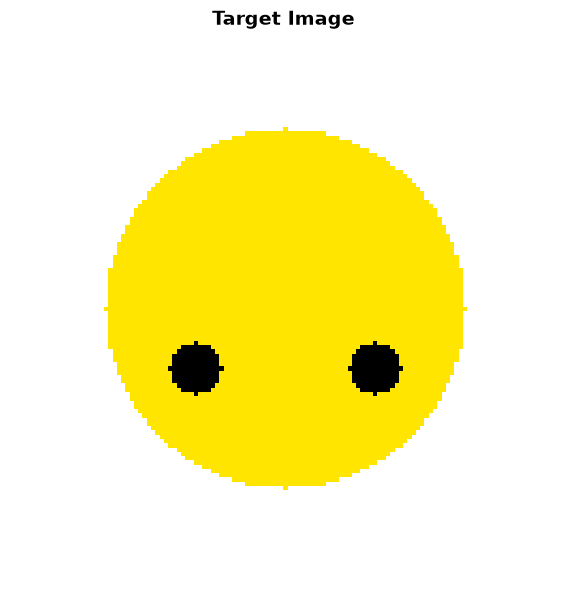

Target image shape: torch.Size([128, 128, 3])


In [63]:
# Create the target smiley face image
target_image_np = create_face(IMAGE_SIZE)
target_image = torch.from_numpy(target_image_np).to(device)

# Visualize
plt.figure(figsize=(6, 6))
plt.imshow(target_image_np)
plt.title('Target Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Target image shape: {target_image.shape}")


## Setup Camera

We'll use a simple pinhole camera model:


In [64]:
# Camera parameters
camera_position = torch.tensor([0.0, 0.0, 2.5], device=device)
camera_target = torch.tensor([0.0, 0.0, 0.0], device=device)
camera_up = torch.tensor([0.0, 1.0, 0.0], device=device)

# Create camera
camera = kal.render.camera.Camera.from_args(
    eye=camera_position,
    at=camera_target,
    up=camera_up,
    width=IMAGE_SIZE,
    height=IMAGE_SIZE,
    fov=45.0,
    device=device
)

# Generate rays
ray_orig, ray_dir = kal.render.camera.generate_pinhole_rays(camera)

print(f"Ray origins shape: {ray_orig.shape}")
print(f"Ray directions shape: {ray_dir.shape}")
print(f"Total rays: {ray_orig.shape[0]:,}")


Ray origins shape: torch.Size([16384, 3])
Ray directions shape: torch.Size([16384, 3])
Total rays: 16,384


## Initialize SPC Structure

We'll create an initial dense grid of points and convert it to an SPC octree:


In [65]:
def initialize_spc_grid(level, device, init_type='sphere'):
    """
    Initialize a grid of 3D points for SPC creation.
    
    Args:
        level: Octree depth (resolution = 2^level)
        device: torch device
        init_type: 'sphere', 'cube', or 'random'
    
    Returns:
        points: (N, 3) tensor of points in [-1, 1]^3
    """
    resolution = 2 ** level
    
    if init_type == 'sphere':
        # Initialize points in a sphere
        # Generate grid
        grid_1d = torch.linspace(-1, 1, resolution, device=device)
        grid_x, grid_y, grid_z = torch.meshgrid(grid_1d, grid_1d, grid_1d, indexing='ij')
        points = torch.stack([grid_x, grid_y, grid_z], dim=-1).reshape(-1, 3)
        
        # Filter to sphere.
        # The radius matters more than it looks: anything the target image
        # covers but this volume does not project onto can never be rendered,
        # which puts a hard floor under the loss. 1.0 fills the view frustum.
        distances = torch.norm(points, dim=-1)
        sphere_mask = distances <= SPHERE_RADIUS
        points = points[sphere_mask]
        
    elif init_type == 'cube':
        # Full cube
        grid_1d = torch.linspace(-0.8, 0.8, resolution, device=device)
        grid_x, grid_y, grid_z = torch.meshgrid(grid_1d, grid_1d, grid_1d, indexing='ij')
        points = torch.stack([grid_x, grid_y, grid_z], dim=-1).reshape(-1, 3)
        
    elif init_type == 'random':
        # Random sparse points
        num_points = (2 ** level) ** 3 // 4  # Quarter of full resolution
        points = torch.rand(num_points, 3, device=device) * 1.6 - 0.8
    
    else:
        raise ValueError(f"Unknown init_type: {init_type}")
    
    return points

# Initialize point cloud
initial_points = initialize_spc_grid(SPC_LEVEL, device, init_type='sphere')

print(f"Initialized {initial_points.shape[0]:,} points")
print(f"Point cloud bounds: [{initial_points.min():.3f}, {initial_points.max():.3f}]")


Initialized 15,408 points
Point cloud bounds: [-0.935, 0.935]


In [ ]:
# Build the SPC. This is the octree the renderer traverses: the raytracer
# below descends it to find which voxels each ray actually passes through.
spc = kal.ops.conversions.pointcloud.unbatched_pointcloud_to_spc(
    initial_points,
    level=SPC_LEVEL
)

octree          = spc.octrees            # the tree itself, one byte per node
point_hierarchy = spc.point_hierarchies  # every level's points, packed together
pyramid         = spc.pyramids[0]        # [counts; offsets] per level
exsum           = spc.exsum              # prefix sums the traversal needs

# Occupied voxels at the finest level live in one contiguous block of
# point_hierarchy. Everything we optimize is indexed against that block.
level_start = int(pyramid[1][SPC_LEVEL])
num_voxels  = int(pyramid[0][SPC_LEVEL])

# Leaf centres back in [-1, 1], for the 3D plot at the end.
leaf_points = (point_hierarchy[level_start:level_start + num_voxels].float()
               / (2 ** SPC_LEVEL)) * 2.0 - 1.0

print(f"Octree:           {len(octree)} bytes")
print(f"Points per level: {pyramid[0][:SPC_LEVEL + 1].tolist()}")
print(f"Leaf voxels (L{SPC_LEVEL}): {num_voxels:,}")
print(f"Packed hierarchy: {point_hierarchy.shape[0]:,} points across all levels")


In [67]:
# Initialize per-voxel features (density + color).
# One entry per octree leaf, in the SPC's own ordering - the conversion sorts
# points into Morton order, so this is NOT the order of initial_points.
voxel_density = torch.randn(num_voxels, 1, device=device) * 0.1 + 0.5
voxel_density.requires_grad = True

voxel_color = torch.rand(num_voxels, 3, device=device) * 0.5 + 0.25
voxel_color.requires_grad = True

print(f"Voxel density shape: {voxel_density.shape}")
print(f"Voxel color shape: {voxel_color.shape}")
print(f"\nTotal parameters to optimize: {(num_voxels * 4):,}")


Voxel density shape: torch.Size([15408, 1])
Voxel color shape: torch.Size([15408, 3])

Total parameters to optimize: 61,632


## Differentiable SPC Rendering

This is the core of our tutorial - rendering SPCs with gradients!

**Key Kaolin functions:**
- `kaolin.render.spc.unbatched_raytrace`: Fast octree ray-voxel intersection
- `kaolin.render.spc.exponential_integration`: Volume rendering equation


In [ ]:
def render_spc(ray_orig, ray_dir, voxel_density, voxel_color):
    """Differentiable SPC rendering through the octree.

    Two Kaolin calls do the work:
      unbatched_raytrace       - walks the octree and returns, per ray, the
                                 leaves it passes through and where it enters
                                 and leaves each one
      exponential_integration  - the volume rendering equation over those hits

    The raytracer descends only into occupied nodes, so empty space costs
    nothing and the work scales with what a ray actually hits.
    """
    num_rays = ray_orig.shape[0]

    # ridx  : which ray this intersection belongs to (sorted, so hits form packs)
    # pidx  : index into point_hierarchy of the leaf that was hit
    # depth : (entry, exit) distance along the ray for that leaf
    ridx, pidx, depth = kal.render.spc.unbatched_raytrace(
        octree, point_hierarchy, pyramid, exsum,
        ray_orig, ray_dir, SPC_LEVEL,
        return_depth=True, with_exit=True
    )

    if ridx.shape[0] == 0:                      # camera missed the volume
        return torch.ones(num_rays, 3, device=ray_orig.device)

    # pidx addresses the whole packed hierarchy; shift it into our leaf block
    feat_idx = pidx.long() - level_start

    # optical thickness = density x how far the ray travelled inside the voxel
    segment = (depth[:, 1] - depth[:, 0]).clamp(min=0).unsqueeze(-1)
    tau = torch.sigmoid(voxel_density[feat_idx]) * segment * 10.0

    # voxel_color is already an RGB value in [0, 1] (the training loop clamps
    # it), so it is used directly. Only the density needs squashing into (0, 1).
    rgb_per_hit = voxel_color[feat_idx]

    # boundaries mark where each ray's run of intersections begins
    boundaries = kal.render.spc.mark_pack_boundaries(ridx)

    rgb, _ = kal.render.spc.exponential_integration(
        rgb_per_hit, tau, boundaries, exclusive=True
    )

    # what is left over after the volume: the white background
    background = torch.exp(-kal.render.spc.sum_reduce(tau, boundaries))

    # rays that hit nothing keep the background; the rest get their integral
    image = torch.ones(num_rays, 3, device=ray_orig.device)
    image = image.index_put((ridx[boundaries].long(),), rgb + background)
    return torch.clamp(image, 0, 1)


print("SPC rendering function defined - octree raytracing.")


## Test Initial Rendering


Rendering initial SPC...


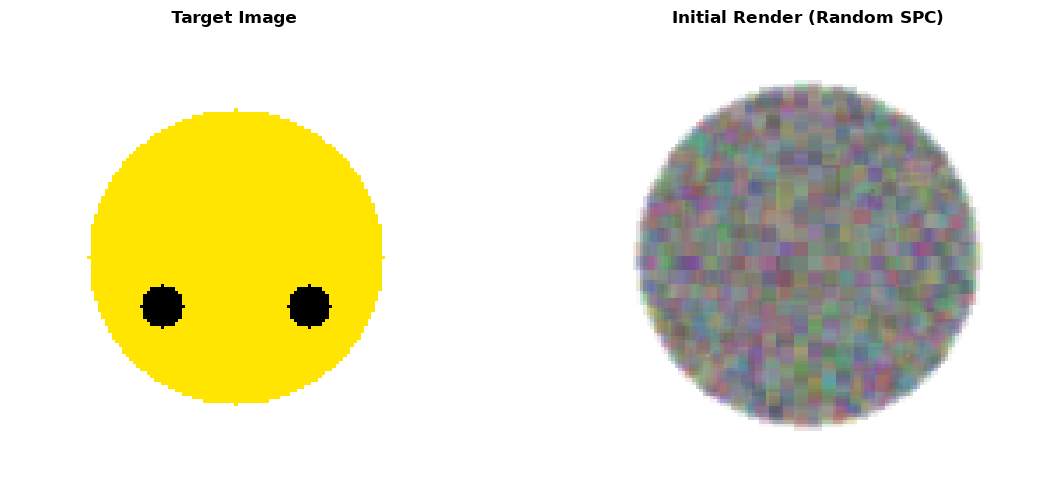

[SUCCESS] Initial rendering complete!


In [69]:
print("Rendering initial SPC...")
with torch.no_grad():
    initial_render = render_spc(
        ray_orig, ray_dir, voxel_density, voxel_color
    )

initial_render_img = initial_render.reshape(IMAGE_SIZE, IMAGE_SIZE, 3).cpu().numpy()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(target_image_np)
axes[0].set_title('Target Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(initial_render_img)
axes[1].set_title('Initial Render (Random SPC)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("[SUCCESS] Initial rendering complete!")


## Neural Optimization Loop

Now we'll optimize the SPC voxel features (density and color) to match the target image!


Starting optimization for 300 iterations...
Parameters: 61,632 (density + RGB per voxel)



Optimizing SPC:   0%|          | 0/300 [00:00<?, ?it/s]

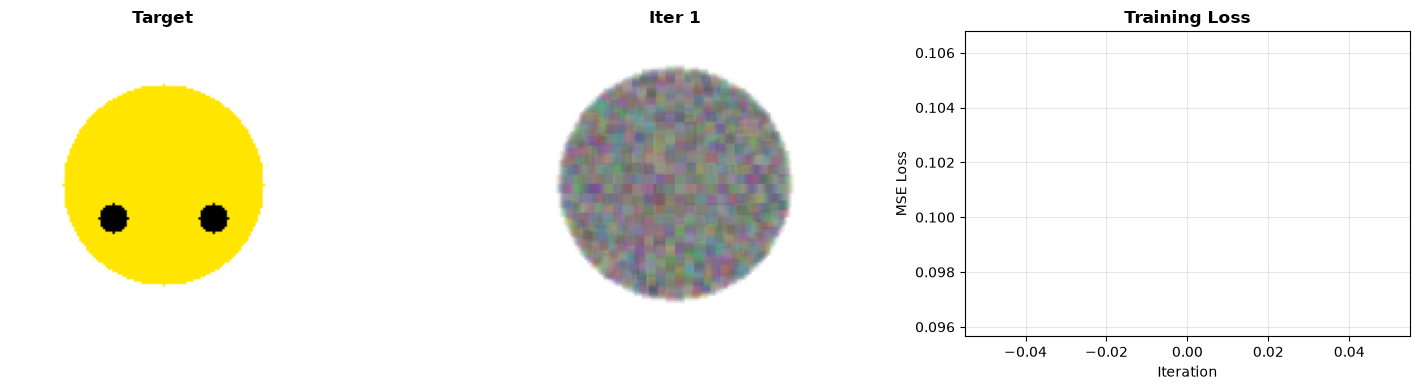

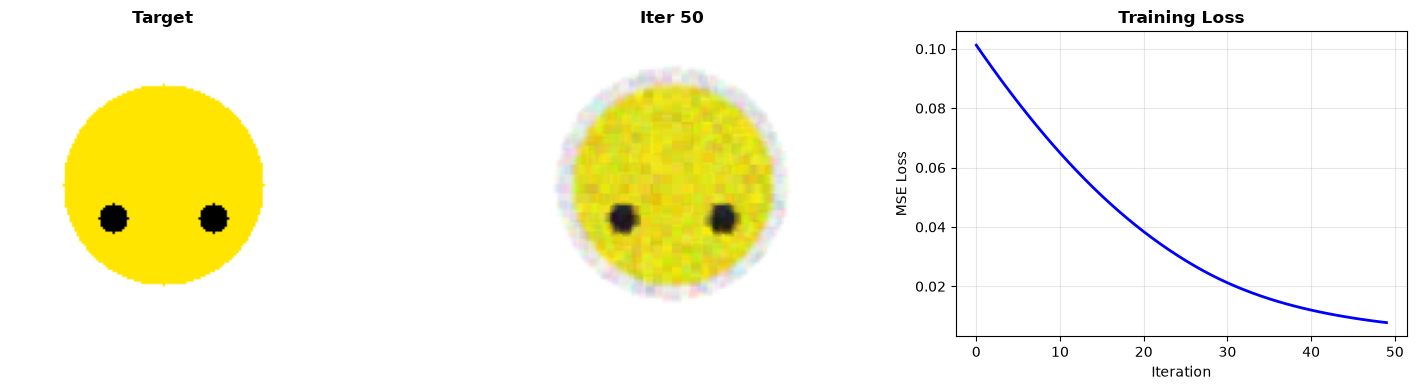

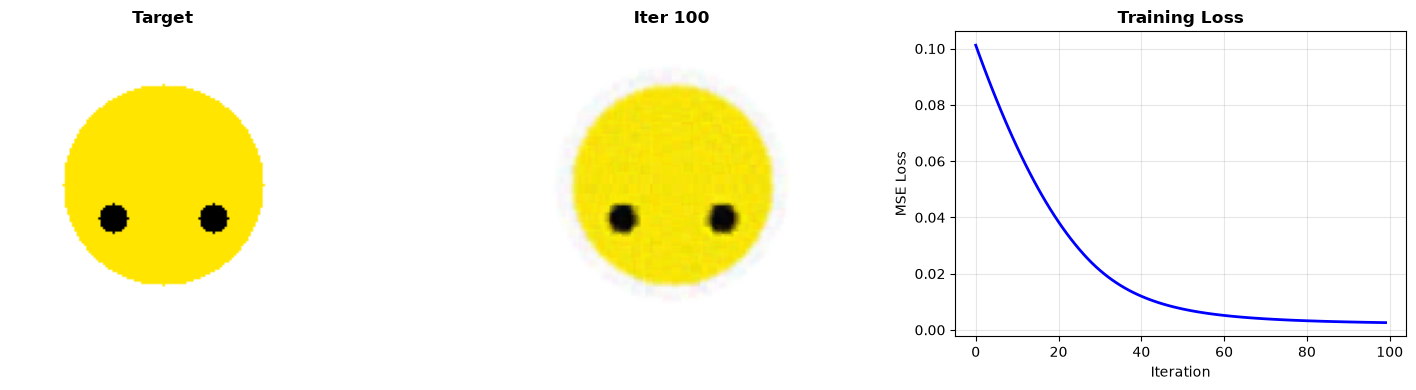

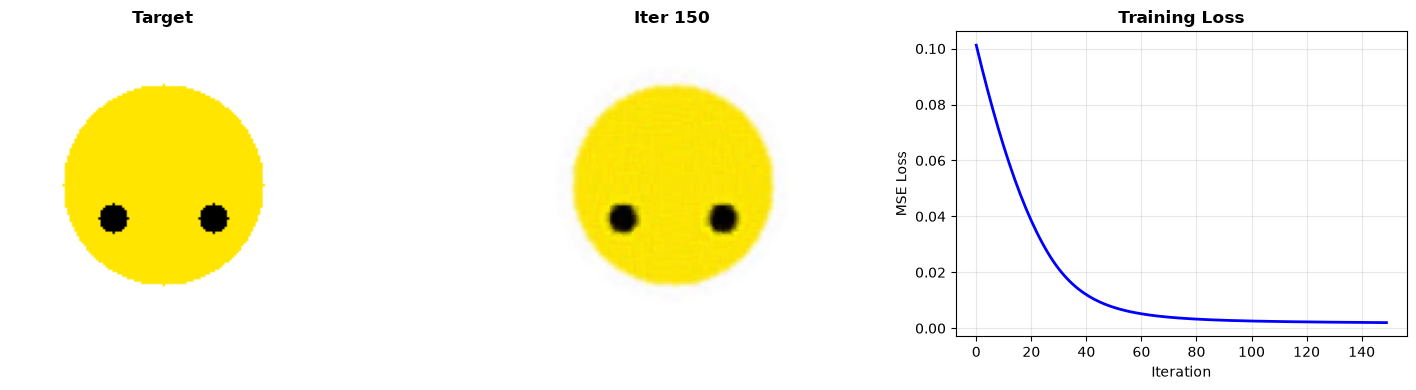

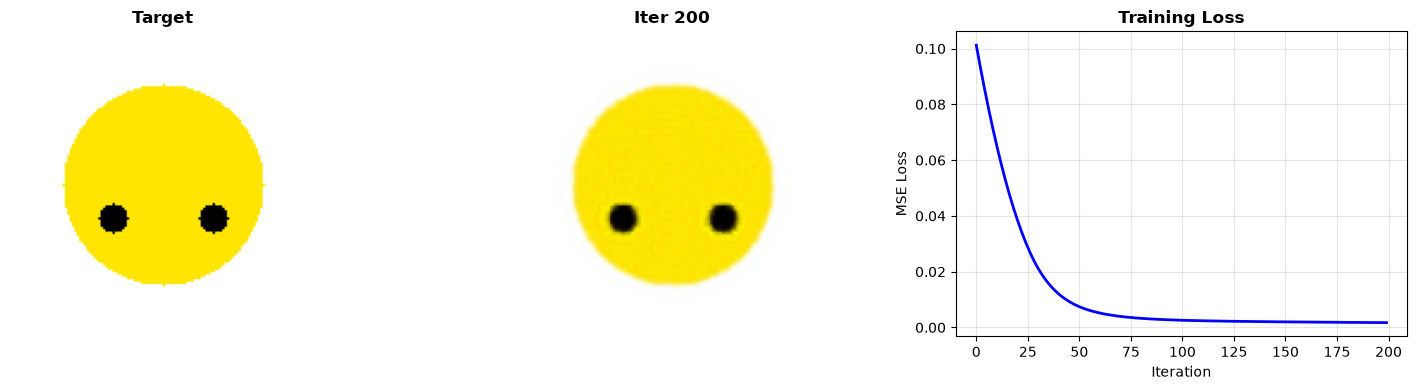

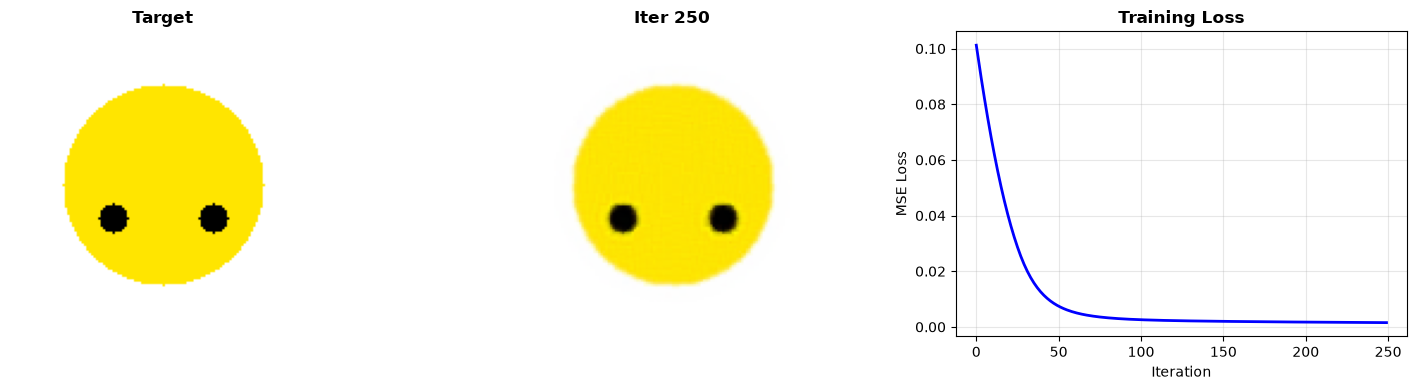

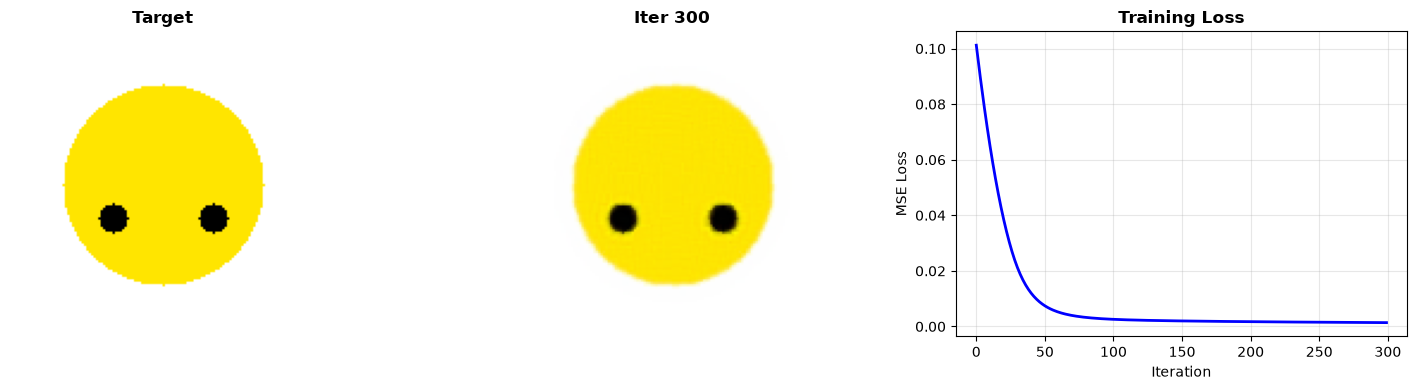


[SUCCESS] Optimization complete!


In [70]:
# Setup optimizer
optimizer = torch.optim.Adam([voxel_density, voxel_color], lr=LEARNING_RATE)

# Training history
losses = []
iterations = []

print(f"Starting optimization for {NUM_ITERATIONS} iterations...")
print(f"Parameters: {num_voxels * 4:,} (density + RGB per voxel)\n")

# Training loop
progress_bar = tqdm(range(NUM_ITERATIONS), desc="Optimizing SPC")

for iteration in progress_bar:
    # Render current SPC
    rendered = render_spc(
        ray_orig, ray_dir, voxel_density, voxel_color
    )
    
    # Reshape to image
    rendered_image = rendered.reshape(IMAGE_SIZE, IMAGE_SIZE, 3)
    
    # Compute loss (MSE between rendered and target)
    loss = F.mse_loss(rendered_image, target_image)
    
    # Add regularization to prevent extreme values
    density_reg = 0.001 * torch.mean(torch.abs(voxel_density))
    color_reg = 0.001 * torch.mean(torch.abs(voxel_color - 0.5))
    total_loss = loss + density_reg + color_reg
    
    # Backpropagation
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # Clamp values to reasonable ranges
    with torch.no_grad():
        voxel_color.clamp_(0, 1)
        voxel_density.clamp_(-6, 6)
    
    # Record loss
    losses.append(loss.item())
    iterations.append(iteration)
    
    # Update progress bar
    progress_bar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    # Visualize progress
    if (iteration + 1) % PLOT_EVERY == 0 or iteration == 0:
        with torch.no_grad():
            current_render = rendered_image.cpu().numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            
            axes[0].imshow(target_image_np)
            axes[0].set_title('Target', fontweight='bold')
            axes[0].axis('off')
            
            axes[1].imshow(current_render)
            axes[1].set_title(f'Iter {iteration+1}', fontweight='bold')
            axes[1].axis('off')
            
            axes[2].plot(iterations, losses, 'b-', linewidth=2)
            axes[2].set_xlabel('Iteration')
            axes[2].set_ylabel('MSE Loss')
            axes[2].set_title('Training Loss', fontweight='bold')
            axes[2].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

print("\n[SUCCESS] Optimization complete!")


## Final Results


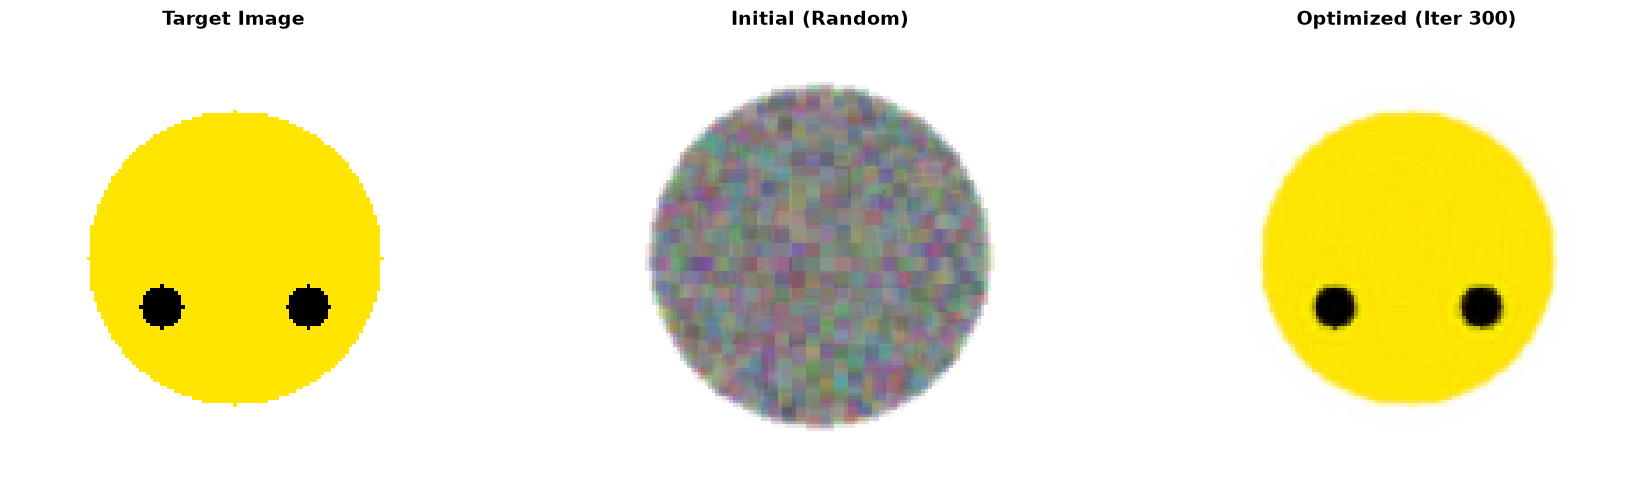

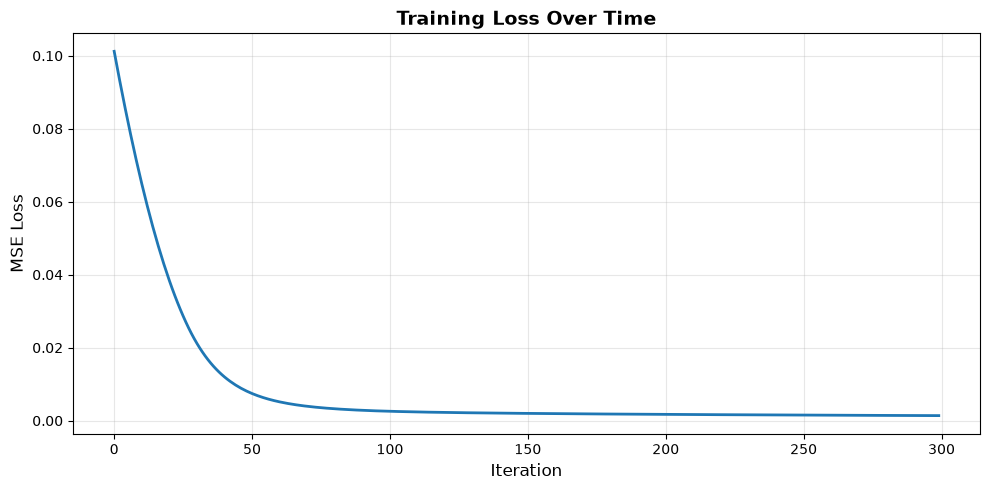

Final loss: 0.001387
Initial loss: 0.101214
Improvement: 98.6%


In [71]:
# Final rendering
with torch.no_grad():
    final_render = render_spc(
        ray_orig, ray_dir, voxel_density, voxel_color
    )
    final_render_img = final_render.reshape(IMAGE_SIZE, IMAGE_SIZE, 3).cpu().numpy()

# Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(target_image_np)
axes[0].set_title('Target Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(initial_render_img)
axes[1].set_title('Initial (Random)', fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(final_render_img)
axes[2].set_title(f'Optimized (Iter {NUM_ITERATIONS})', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Loss curve
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training Loss Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss: {losses[-1]:.6f}")
print(f"Initial loss: {losses[0]:.6f}")
print(f"Improvement: {((losses[0] - losses[-1]) / losses[0] * 100):.1f}%")


## 3D Visualization

Let's visualize the learned 3D structure!

The visualization shows the active voxels (density > 0.5) from a **front view** - the same angle as the rendering camera. You should clearly see:
- **Yellow sphere**: The learned face shape
- **Black regions**: The two eyes on the front face
- **3D depth**: The volumetric structure

**Interactive controls:** Rotate, zoom, and pan to explore the 3D structure from all angles!


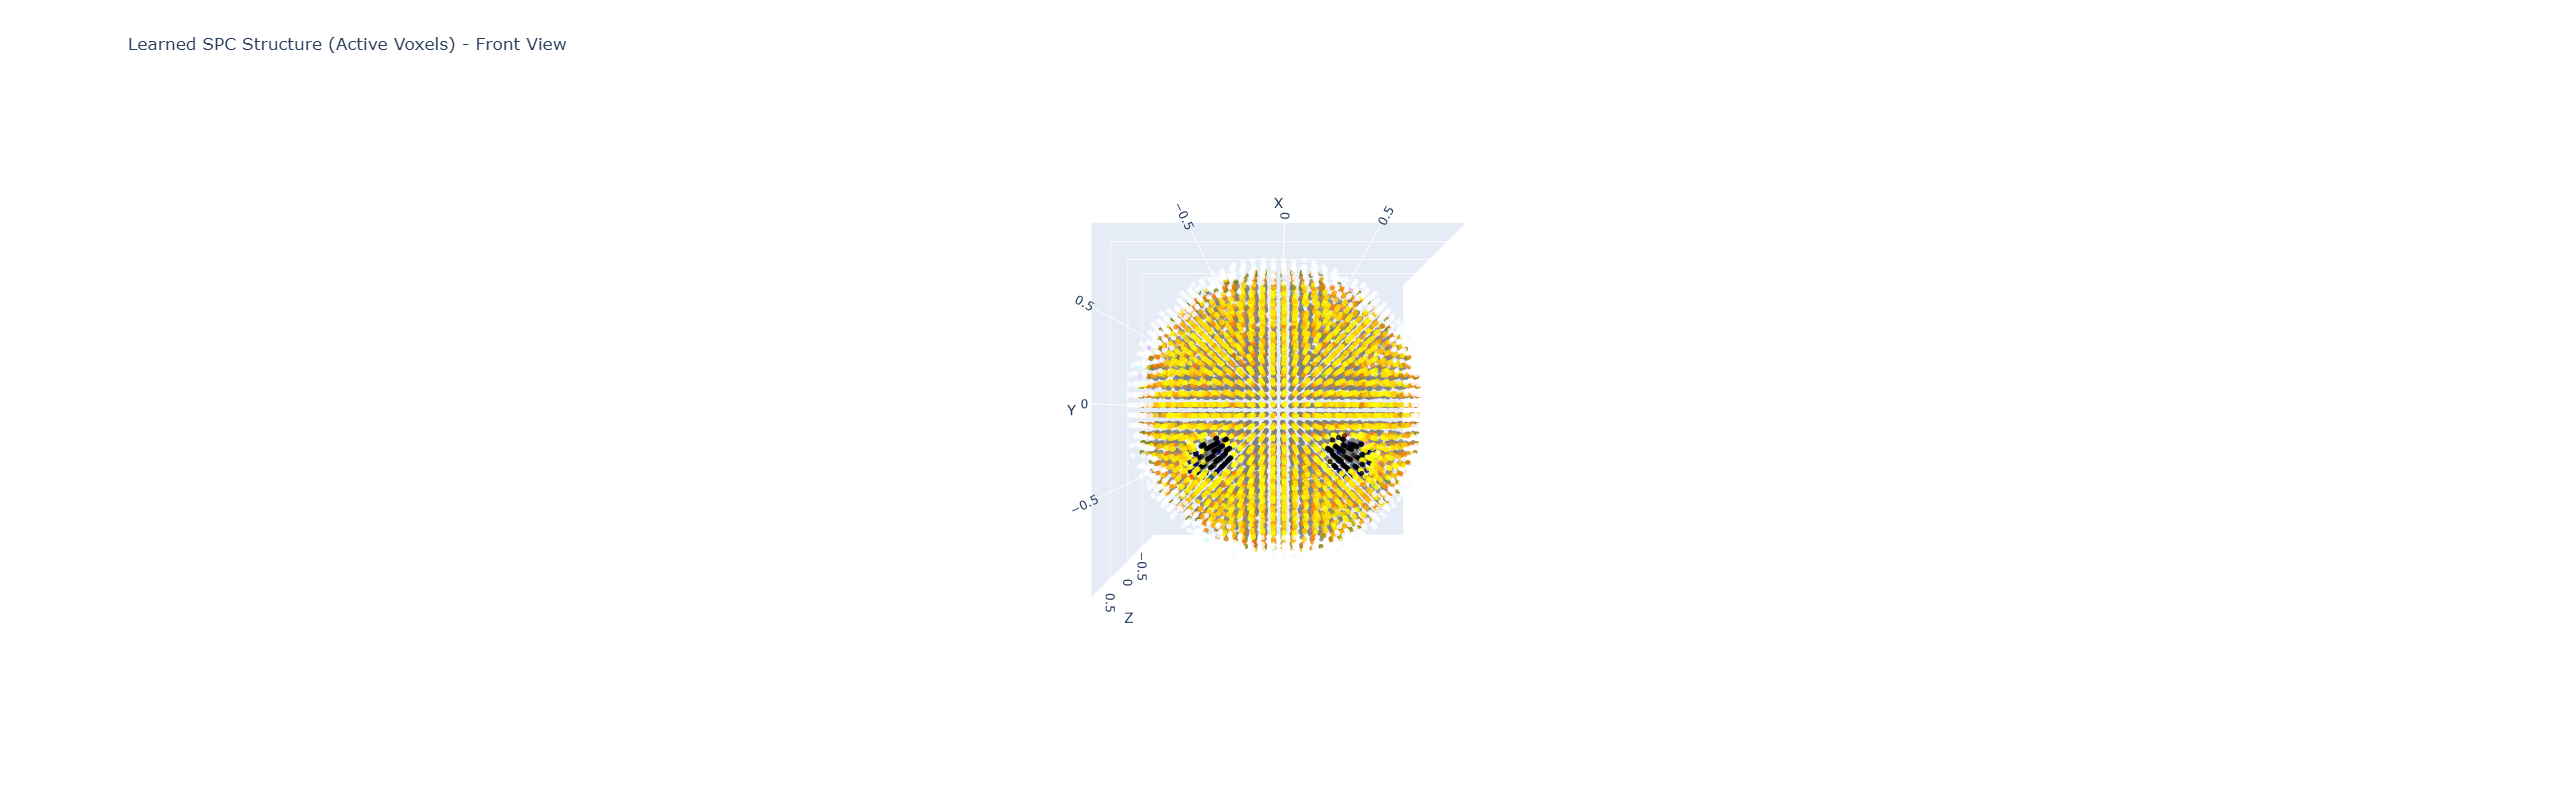

Visualizing 8,462 active voxels (density > 0.5)
TIP: You can rotate, zoom, and pan the 3D view interactively!


In [72]:
# Check if plotly is available
try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not available. Install with: pip install plotly")

if PLOTLY_AVAILABLE:
    # Get active voxels (high density)
    with torch.no_grad():
        active_mask = torch.sigmoid(voxel_density.squeeze()) > 0.5
        # features are indexed by octree leaf, so plot the leaf centres
        active_points = leaf_points[active_mask].cpu().numpy()
        active_colors = voxel_color[active_mask].cpu().numpy()
        active_densities = voxel_density[active_mask].cpu().numpy()
    
    # Sample for visualization (too many points can be slow)
    max_points = 10000
    if len(active_points) > max_points:
        indices = np.random.choice(len(active_points), max_points, replace=False)
        active_points = active_points[indices]
        active_colors = active_colors[indices]
        active_densities = active_densities[indices]
    
    # Create 3D scatter plot
    fig = go.Figure(data=[go.Scatter3d(
        x=active_points[:, 0],
        y=active_points[:, 1],
        z=active_points[:, 2],
        mode='markers',
        marker=dict(
            size=3,
            color=['rgb({},{},{})'.format(int(c[0]*255), int(c[1]*255), int(c[2]*255)) 
                   for c in active_colors],
            opacity=0.8
        )
    )])
    
    # Set camera to front view (matching the rendering camera angle)
    # This shows the smiley face head-on with eyes clearly visible
    fig.update_layout(
        title='Learned SPC Structure (Active Voxels) - Front View',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='cube',
            camera=dict(
                eye=dict(x=0, y=0, z=2.5),  # Front view (camera looks from +Z)
                center=dict(x=0, y=0, z=0),
                up=dict(x=0, y=1, z=0)
            )
        ),
        width=800,
        height=800
    )
    
    fig.show()
    print(f"Visualizing {len(active_points):,} active voxels (density > 0.5)")
    print("TIP: You can rotate, zoom, and pan the 3D view interactively!")

else:
    # Fallback to matplotlib 3D
    from mpl_toolkits.mplot3d import Axes3D
    
    with torch.no_grad():
        active_mask = torch.sigmoid(voxel_density.squeeze()) > 0.5
        # features are indexed by octree leaf, so plot the leaf centres
        active_points = leaf_points[active_mask].cpu().numpy()
        active_colors = voxel_color[active_mask].cpu().numpy()
    
    # Sample
    if len(active_points) > 5000:
        indices = np.random.choice(len(active_points), 5000, replace=False)
        active_points = active_points[indices]
        active_colors = active_colors[indices]
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(active_points[:, 0], active_points[:, 1], active_points[:, 2],
               c=active_colors, s=10, alpha=0.6)
    
    # Set viewing angle to front view (matching camera)
    ax.view_init(elev=0, azim=0)  # Front view
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Learned SPC - Front View (Install Plotly for interactive view)')
    plt.show()
    print("Note: Install plotly for interactive 3D visualization: pip install plotly")
